In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
bike_df=pd.read_csv('bike_sharing_daily.csv')

In [4]:
bike_df.head(10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered,cnt
0,1,1/1/2011,1,0,1,0,6,0,2,0.344167,0.805833,0.160446,331,654,985
1,2,1/2/2011,1,0,1,0,0,0,2,0.363478,0.696087,0.248539,131,670,801
2,3,1/3/2011,1,0,1,0,1,1,1,0.196364,0.437273,0.248309,120,1229,1349
3,4,1/4/2011,1,0,1,0,2,1,1,0.200000,0.590435,0.160296,108,1454,1562
4,5,1/5/2011,1,0,1,0,3,1,1,0.226957,0.436957,0.186900,82,1518,1600
5,6,1/6/2011,1,0,1,0,4,1,1,0.204348,0.518261,0.089565,88,1518,1606
6,7,1/7/2011,1,0,1,0,5,1,2,0.196522,0.498696,0.168726,148,1362,1510
7,8,1/8/2011,1,0,1,0,6,0,2,0.165000,0.535833,0.266804,68,891,959
8,9,1/9/2011,1,0,1,0,0,0,1,0.138333,0.434167,0.361950,54,768,822
9,10,1/10/2011,1,0,1,0,1,1,1,0.150833,0.482917,0.223267,41,1280,1321


In [5]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  hum         731 non-null    float64
 11  windspeed   731 non-null    float64
 12  casual      731 non-null    int64  
 13  registered  731 non-null    int64  
 14  cnt         731 non-null    int64  
dtypes: float64(3), int64(11), object(1)
memory usage: 85.8+ KB


In [6]:
bike_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**disini kita akan melakukan pemberihan dengan mengubah tipe data di dteday dari object menjadi date time dan mengubahnya menjadi index dan membuang kolom dteday yang ada agar dteday hanya ada di index saja**

In [3]:
bike_df['dteday']=pd.to_datetime(bike_df['dteday'])

disini kita membuat dteday menjadi index dan membuangnya dari kolom

In [3]:
bike_df.set_index(bike_df['dteday'], inplace=True)


In [4]:
bike_df.drop(columns=['instant', 'dteday'], inplace=True)

In [6]:
bike_df.head(10)

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered,cnt
dteday,,,,,,,,,,,,,
2011-01-01,1,0,1,0,6,0,2,0.344167,0.805833,0.160446,331,654,985
2011-01-02,1,0,1,0,0,0,2,0.363478,0.696087,0.248539,131,670,801
2011-01-03,1,0,1,0,1,1,1,0.196364,0.437273,0.248309,120,1229,1349
2011-01-04,1,0,1,0,2,1,1,0.200000,0.590435,0.160296,108,1454,1562
2011-01-05,1,0,1,0,3,1,1,0.226957,0.436957,0.186900,82,1518,1600
2011-01-06,1,0,1,0,4,1,1,0.204348,0.518261,0.089565,88,1518,1606
2011-01-07,1,0,1,0,5,1,2,0.196522,0.498696,0.168726,148,1362,1510
2011-01-08,1,0,1,0,6,0,2,0.165000,0.535833,0.266804,68,891,959
2011-01-09,1,0,1,0,0,0,1,0.138333,0.434167,0.361950,54,768,822


In [7]:
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  hum         731 non-null    float64       
 11  windspeed   731 non-null    float64       
 12  casual      731 non-null    int64         
 13  registered  731 non-null    int64         
 14  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(11)
memory usage: 85.8 KB


disini asfreq mengambil data dari setiap akhir periode waktu perminggu(di hari minggu saja)

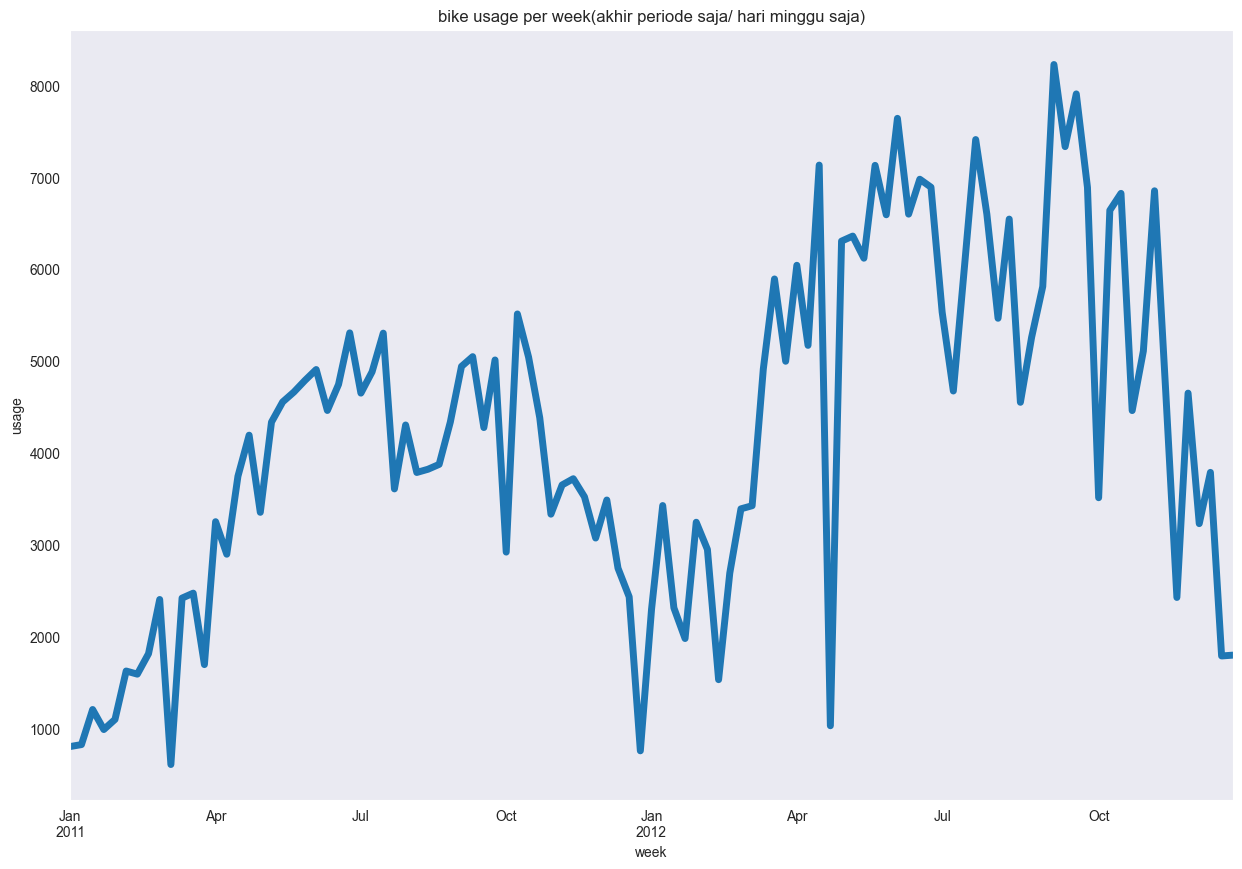

In [18]:
plt.figure(figsize=(15,10))
bike_df['cnt'].asfreq('w').plot(linewidth=5)
plt.title('bike usage per week(akhir periode saja/ hari minggu saja)')
plt.xlabel('week')
plt.ylabel('usage')
plt.grid()

disini nilai yang akan diambil adalah akhir periode dari bulan saja

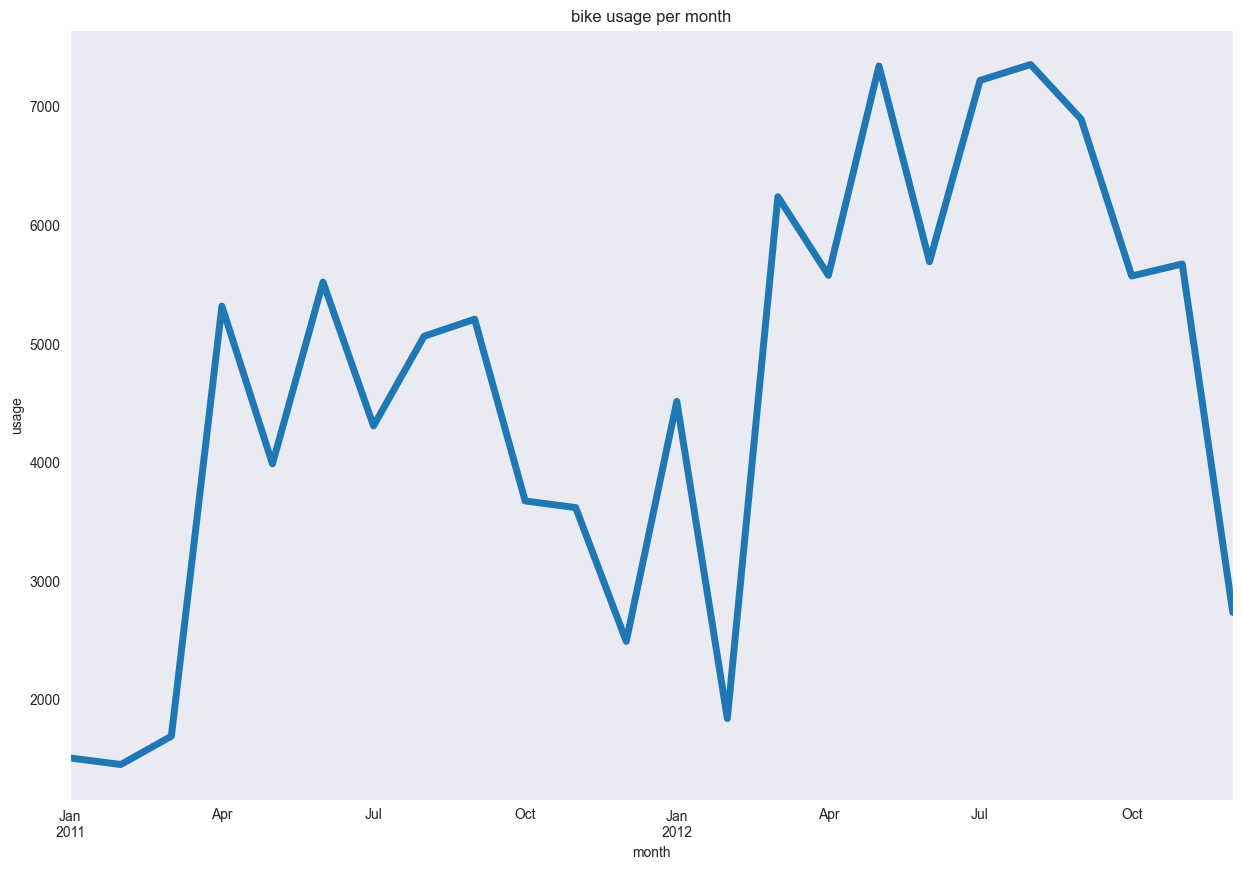

In [13]:
plt.figure(figsize=(15,10))
bike_df['cnt'].asfreq('m').plot(linewidth=5)
plt.title('bike usage per month')
plt.xlabel('month')
plt.ylabel('usage')
plt.grid()

jika memang ingin merekap nilai dalam satu periode penuh bisa menggunakna resample dengan perintah agg, seperti resample(df).mean()

<Axes: >

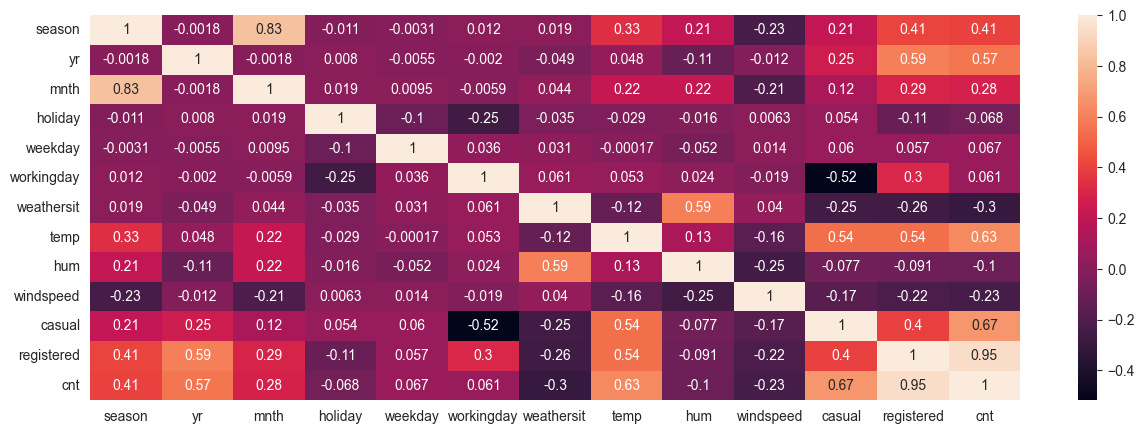

In [20]:
plt.figure(figsize=(15,5))
sns.heatmap(bike_df.corr(numeric_only=True),annot=True)

disini kita akan membuat model untuk memprediksi nilai casual dan register dari peminjaman sepeda

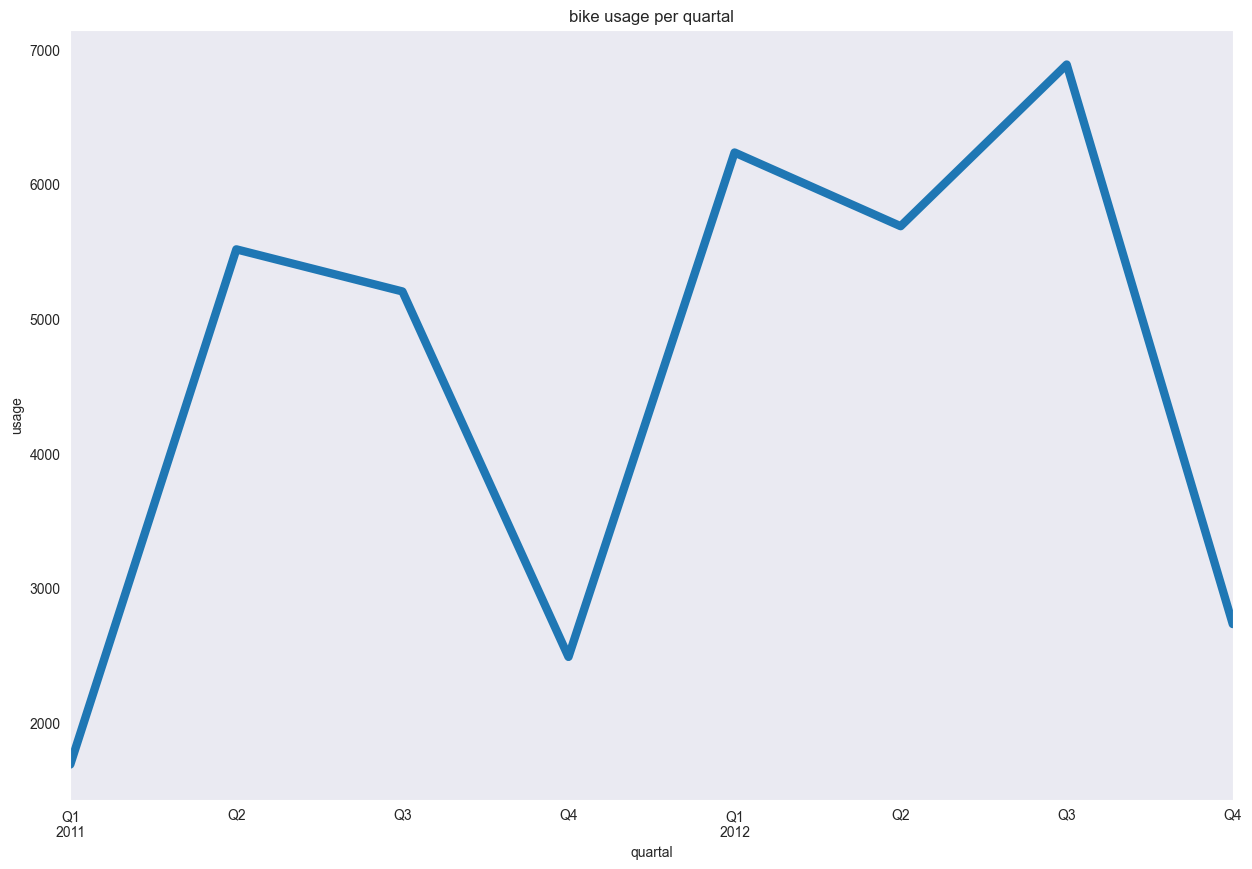

In [8]:
plt.figure(figsize=(15,10))
bike_df['cnt'].asfreq('q').plot(linewidth=6)
plt.title('bike usage per quartal')
plt.xlabel('quartal')
plt.ylabel('usage')
plt.grid()

sekarang kita akan meng encode data categotikal

In [13]:
bike_df['weathersit'].unique()

array([2, 1, 3])

In [3]:
x_cat=bike_df[['season','mnth','weekday','weathersit']]

disini hasil encode diubah menjadi array agar bisa dibaca, karena hasil dari encode default adalah titik koordinat saja

In [4]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder()
x_cat=encoder.fit_transform(x_cat).toarray()
x_cat.shape

(731, 26)

disini saya mengecek kolom mana saja yang kategorikal dan harus di encode, karena yr,working day,week day adalah kolom bertipe binary(1,0) maka tidak usah di encode

In [20]:
for i in bike_df.columns:
    print(i)
    print(bike_df[i].unique())
    print("\n")

season
[1 2 3 4]


yr
[0 1]


mnth
[ 1  2  3  4  5  6  7  8  9 10 11 12]


holiday
[0 1]


weekday
[6 0 1 2 3 4 5]


workingday
[0 1]


weathersit
[2 1 3]


temp
[0.344167  0.363478  0.196364  0.2       0.226957  0.204348  0.196522
 0.165     0.138333  0.150833  0.169091  0.172727  0.16087   0.233333
 0.231667  0.175833  0.216667  0.292174  0.261667  0.1775    0.0591304
 0.0965217 0.0973913 0.223478  0.2175    0.195     0.203478  0.216522
 0.180833  0.192174  0.26      0.186957  0.211304  0.285833  0.271667
 0.220833  0.134783  0.144348  0.189091  0.2225    0.316522  0.415
 0.266087  0.318261  0.435833  0.521667  0.399167  0.285217  0.303333
 0.182222  0.221739  0.295652  0.364348  0.2825    0.343478  0.407273
 0.266667  0.335     0.198333  0.384167  0.376522  0.261739  0.2925
 0.295833  0.389091  0.329167  0.384348  0.325217  0.317391  0.365217
 0.54      0.4725    0.3325    0.430435  0.441667  0.346957  0.285
 0.264167  0.265833  0.253043  0.264348  0.3025    0.3       0.268333
 0.31

In [7]:
x_numerical=bike_df[['temp','hum','windspeed','casual','registered','cnt','yr','holiday','workingday']]

In [24]:
x_numerical.head(10)

,temp,hum,windspeed,casual,registered,cnt
dteday,,,,,,
2011-01-01,0.344167,0.805833,0.160446,331,654,985
2011-01-02,0.363478,0.696087,0.248539,131,670,801
2011-01-03,0.196364,0.437273,0.248309,120,1229,1349
2011-01-04,0.200000,0.590435,0.160296,108,1454,1562
2011-01-05,0.226957,0.436957,0.186900,82,1518,1600
2011-01-06,0.204348,0.518261,0.089565,88,1518,1606
2011-01-07,0.196522,0.498696,0.168726,148,1362,1510
2011-01-08,0.165000,0.535833,0.266804,68,891,959
2011-01-09,0.138333,0.434167,0.361950,54,768,822


disini kita akan mengganti index yang seblumnya adalah dteday/ tanggal dengan index numeric, dan dengan drop=true kita akan membuang index lama dan hanya menyisakan kolom index baru saja

In [6]:
x_numerical.reset_index(drop=True, inplace=True)

NameError: name 'x_numerical' is not defined

In [7]:
x_numerical.head(5)

,temp,hum,windspeed,casual,registered,cnt,yr,holiday,workingday
0,0.344167,0.805833,0.160446,331,654,985,0,0,0
1,0.363478,0.696087,0.248539,131,670,801,0,0,0
2,0.196364,0.437273,0.248309,120,1229,1349,0,0,1
3,0.200000,0.590435,0.160296,108,1454,1562,0,0,1
4,0.226957,0.436957,0.186900,82,1518,1600,0,0,1


disini kita menggunakan get_feature_names_out agar nama kolom yang sebelumnya di encode bisa kembali, karen jika tidak maka nama kolom akan membawa nama biner dari array

In [8]:
x_cat=pd.DataFrame(x_cat,columns=encoder.get_feature_names_out(),index=x_numerical.index)

In [44]:
x_cat.head(10)

,season_1,season_2,season_3,season_4,mnth_1,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,...,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_1,weathersit_2,weathersit_3
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
6,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
8,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [9]:
x_all=pd.concat([x_numerical,x_cat],axis=1)

In [10]:
x_all2=x_all.drop(columns=['casual','registered'])

jadi disini kita akan mensplit data kita menjadi 3 bagian, x y dan cnt, karena sebenarnya data yang di prediksi itu harusnya ada dua yaitu register dan casual dan cnt adalah hasil penjumlahan dari keduanya

jadi disini kita bisa mengambil data dari df tanpa menggunakan drop,dengan integer location kita bisa langsung mengambil data dengan format[baris,kolom] dengan ketentuan jika kita menggunakan":" maka kita mengambil semuanya dan jika menggunakan -1 maka yang diambul hanya baris terakhir dan jika dengan ":-3" maka kita mengambil semua data kecuali tiga terakhir

In [57]:
x_all

,temp,hum,windspeed,casual,registered,cnt,yr,holiday,workingday,season_1,...,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_1,weathersit_2,weathersit_3
0,0.344167,0.805833,0.160446,331,654,985,0,0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.363478,0.696087,0.248539,131,670,801,0,0,0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.196364,0.437273,0.248309,120,1229,1349,0,0,1,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.200000,0.590435,0.160296,108,1454,1562,0,0,1,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.226957,0.436957,0.186900,82,1518,1600,0,0,1,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,0.254167,0.652917,0.350133,247,1867,2114,1,0,1,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
727,0.253333,0.590000,0.155471,644,2451,3095,1,0,1,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
728,0.253333,0.752917,0.124383,159,1182,1341,1,0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
729,0.255833,0.483333,0.350754,364,1432,1796,1,0,0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


pembagian data untuk multi output

In [9]:
x=x_all.drop(columns=['casual','registered','cnt'])
y=x_all[['casual','registered']]
cnt=x_all['cnt']

single output

In [11]:
x2=x_all2.drop(columns=['cnt'])
y2=x_all['cnt']

In [53]:
x_all2

,temp,hum,windspeed,cnt,yr,holiday,workingday,season_1,season_2,season_3,...,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_1,weathersit_2,weathersit_3
0,0.344167,0.805833,0.160446,985,0,0,0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.363478,0.696087,0.248539,801,0,0,0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.196364,0.437273,0.248309,1349,0,0,1,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.200000,0.590435,0.160296,1562,0,0,1,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.226957,0.436957,0.186900,1600,0,0,1,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,0.254167,0.652917,0.350133,2114,1,0,1,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
727,0.253333,0.590000,0.155471,3095,1,0,1,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
728,0.253333,0.752917,0.124383,1341,1,0,0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
729,0.255833,0.483333,0.350754,1796,1,0,0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


multi output

In [11]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test,cnt_train,cnt_test= train_test_split(x, y,cnt, test_size=0.2, random_state=42)

NameError: name 'x' is not defined

single output

In [12]:
from sklearn.model_selection import train_test_split
x2_train,x2_test,y2_train,y2_test=train_test_split(x2, y2, test_size=0.2, random_state=42)

In [50]:
print(x_train.shape)
print(x_test.shape)

(584, 29)
(147, 29)


In [15]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.multioutput import MultiOutputRegressor

single output

In [13]:
from xgboost import XGBRegressor
model_xgb2=XGBRegressor(objective='reg:squarederror',learning_rate=0.01,n_estimators=3000,max_depth=6,random_state=42)
model_xgb2.fit(x2_train, y2_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [16]:
y_pred=model_xgb2.predict(x2_test)
print("mse:",mean_squared_error(y2_test,y_pred))
print("r2:",r2_score(y2_test,y_pred))
print("mae:",mean_absolute_error(y2_test,y_pred))
print("rmse:",np.sqrt(mean_squared_error(y2_test,y_pred)))

mse: 424180.75
r2: 0.8942161798477173
mae: 438.57110595703125
rmse: 651.2916013584085


multi output

In [12]:
from xgboost import XGBRegressor
model_xgb=MultiOutputRegressor(XGBRegressor(objective='reg:squarederror',gamma= 0,
 learning_rate= 0.01,
 max_depth= 5,
 min_child_weight=3,
 n_estimators= 1000,
 subsample=0.5,random_state=42))
model_xgb.fit(x_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,n_jobs,None
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None


In [13]:
y_pred=model_xgb.predict(x_test)
print("mse:",mean_squared_error(y_test,y_pred))
print("r2:",r2_score(y_test,y_pred))
print("mae:",mean_absolute_error(y_test,y_pred))
print("rmse:",np.sqrt(mean_squared_error(y_test,y_pred)))

mse: 153286.859375
r2: 0.881672203540802
mae: 233.36949157714844
rmse: 391.5186577610319


In [14]:
pred_total=y_pred[:,1]+y_pred[:,0]

ini adalah hasil final dari multi output, setelah kita memprediksi  casual dan register, sekarang kita akan membuat variabel ypred_total yaitu hasil prediksi casual dan register ditambahkan dan nantinya akan dibandingkan hasilnya dengan cnt_tes

In [15]:
print("mse:",mean_squared_error(cnt_test,pred_total))
print("r2:",r2_score(cnt_test,pred_total))
print("mae:",mean_absolute_error(cnt_test,pred_total))
print("rmse:",np.sqrt(mean_squared_error(cnt_test,pred_total)))

mse: 381654.0625
r2: 0.9048216342926025
mae: 394.7473449707031
rmse: 617.781565361091


**sekarang kita akan menggunakan metode optimasi model dengan grid search**

In [24]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
param={
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.05,0.1],
    'n_estimators':[200,500,1000,2000],
    'subsample':[0.5,0.8,0.9],
    'min_child_weight':[3,4,5],
    'gamma':[0,0.1,0.3]
}

karena grid akan selalu mencari hasil nilai tertinggi sebagai juara sedangkan mse mengeluarkan nilai serendah mungkin sebagai juara, maka kita kuganakan hasil mse di negatifkan agar nilai negatif paling besar yang dikeluarkan dari mse bisa diambil sebagai juara oleh grid,ini sesuai dengan rumusan matematika

In [25]:
model_grid_xgb=GridSearchCV(
    estimator=XGBRegressor(random_state=42,objective='reg:squarederror'),
    param_grid=param,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=5
)

dengan total 2916 loop percobaan dan waktu hingga 32 menit untuk mencoba semua kombinasi hyper parameter dengan grid ini

In [26]:
model_grid_xgb.fit(x2_train, y2_train)

Fitting 3 folds for each of 972 candidates, totalling 2916 fits
[CV 1/3] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=200, subsample=0.5;, score=-740005.250 total time=   0.0s
[CV 2/3] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=200, subsample=0.5;, score=-797076.188 total time=   0.0s
[CV 3/3] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=200, subsample=0.5;, score=-628537.000 total time=   0.0s
[CV 1/3] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=200, subsample=0.8;, score=-754584.562 total time=   0.0s
[CV 2/3] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=200, subsample=0.8;, score=-834215.438 total time=   0.0s
[CV 3/3] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=200, subsample=0.8;, score=-644173.000 total time=   0.0s
[CV 1/3] END gamma=0, learning_rate=0.01, max_depth=3, min_c

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [3, 4, ...], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,5
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [27]:
model_grid_xgb.best_params_

{'gamma': 0,
 'learning_rate': 0.01,
 'max_depth': 5,
 'min_child_weight': 3,
 'n_estimators': 1000,
 'subsample': 0.5}

In [32]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_predict_xgb=model_grid_xgb.predict(x2_test)
print("mse:",mean_squared_error(y2_test,y_predict_xgb))
print("r2:",r2_score(y2_test,y_predict_xgb))
print("mae:",mean_absolute_error(y2_test,y_predict_xgb))
print("rmse:",np.sqrt(mean_squared_error(y2_test,y_predict_xgb)))

mse: 366763.65625
r2: 0.9085350632667542
mae: 396.2320861816406
rmse: 605.6101520367703


**sekarang kita akan menggunakan random search**

In [13]:
from sklearn.model_selection import RandomizedSearchCV

In [15]:
param={
    'max_depth':[2,3,5,6,7],
    'learning_rate':[0.01,0.05,0.1],
    'n_estimators':[200,500,1000,2000],
    'subsample':[0.1,0.2,0.4,0.5,0.8,0.9],
    'min_child_weight':[3,4,5],
    'gamma':[0,0.1,0.3]
}

In [16]:
from xgboost import XGBRegressor
random_cv=RandomizedSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror',random_state=42),
    param_distributions=param,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=5,
    n_iter=270
)

In [17]:
random_cv.fit(x2_train, y2_train)

Fitting 3 folds for each of 270 candidates, totalling 810 fits
[CV 1/3] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=4, n_estimators=2000, subsample=0.1;, score=-433971.281 total time=   1.0s
[CV 2/3] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=4, n_estimators=2000, subsample=0.1;, score=-444871.625 total time=   0.9s
[CV 3/3] END gamma=0, learning_rate=0.01, max_depth=7, min_child_weight=4, n_estimators=2000, subsample=0.1;, score=-435026.469 total time=   1.1s
[CV 1/3] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=4, n_estimators=2000, subsample=0.8;, score=-399798.969 total time=   0.6s
[CV 2/3] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=4, n_estimators=2000, subsample=0.8;, score=-483334.344 total time=   0.6s
[CV 3/3] END gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=4, n_estimators=2000, subsample=0.8;, score=-442399.062 total time=   0.6s
[CV 1/3] END gamma=0, learning_rate=0.1, max_depth=6, m

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'min_child_weight': [3, 4, ...], ...}"
,n_iter,270
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,5
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [18]:
random_cv.best_params_

{'subsample': 0.2,
 'n_estimators': 1000,
 'min_child_weight': 3,
 'max_depth': 7,
 'learning_rate': 0.01,
 'gamma': 0.1}

In [19]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_predict_xgb=random_cv.predict(x2_test)
print("mse:",mean_squared_error(y2_test,y_predict_xgb))
print("r2:",r2_score(y2_test,y_predict_xgb))
print("mae:",mean_absolute_error(y2_test,y_predict_xgb))
print("rmse:",np.sqrt(mean_squared_error(y2_test,y_predict_xgb)))

mse: 370687.1875
r2: 0.9075565934181213
mae: 398.5970458984375
rmse: 608.8408556429176


**sekarang kita akan mencoba bayesian search**

In [14]:
from skopt import BayesSearchCV
from skopt.space import Real,Integer

In [15]:
param={
    'learning_rate': Real(0.01, 0.5, prior='log-uniform'),
    'n_estimators': Integer(200, 3000),
    'max_depth': Integer(3, 8),
    'min_child_weight': Integer(1, 5),
    'subsample': Real(0.1, 0.9),
    'gamma': Real(0, 0.5)
}

In [16]:
from xgboost import XGBRegressor
model_bayes=BayesSearchCV(
    estimator=XGBRegressor(random_state=42,objective='reg:squarederror'),
    n_iter=150,
    search_spaces=param,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=5
)
model_bayes.fit(x2_train, y2_train)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV 1/3] END gamma=0.2816794614782948, learning_rate=0.06370824028249246, max_depth=5, min_child_weight=5, n_estimators=1910, subsample=0.4560654333555506;, score=-453595.844 total time=   1.2s
[CV 2/3] END gamma=0.2816794614782948, learning_rate=0.06370824028249246, max_depth=5, min_child_weight=5, n_estimators=1910, subsample=0.4560654333555506;, score=-442149.781 total time=   1.0s
[CV 3/3] END gamma=0.2816794614782948, learning_rate=0.06370824028249246, max_depth=5, min_child_weight=5, n_estimators=1910, subsample=0.4560654333555506;, score=-485458.062 total time=   1.0s
Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV 1/3] END gamma=0.020364749978181, learning_rate=0.12950538350516452, max_depth=3, min_child_weight=3, n_estimators=2927, subsample=0.4566902478594109;, score=-429729.000 total time=   1.0s
[CV 2/3] END gamma=0.020364749978181, learning_rate=0.12950538350516452, max_depth=3, min_child_weight=3, n

,estimator,"XGBRegressor(...ree=None, ...)"
,search_spaces,"{'gamma': Real(low=0, h...m='normalize'), 'learning_rate': Real(low=0.01...m='normalize'), 'max_depth': Integer(low=3...m='normalize'), 'min_child_weight': Integer(low=1...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,150
,scoring,'neg_mean_squared_error'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,3


In [17]:
model_bayes.best_params_

OrderedDict([('gamma', 0.5),
             ('learning_rate', 0.01),
             ('max_depth', 8),
             ('min_child_weight', 1),
             ('n_estimators', 3000),
             ('subsample', 0.13206716905544547)])

In [18]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
y_predict_xgb=model_bayes.predict(x2_test)
print("mse:",mean_squared_error(y2_test,y_predict_xgb))
print("r2:",r2_score(y2_test,y_predict_xgb))
print("mae:",mean_absolute_error(y2_test,y_predict_xgb))
print("rmse:",np.sqrt(mean_squared_error(y2_test,y_predict_xgb)))

mse: 379082.75
r2: 0.9054628610610962
mae: 409.27386474609375
rmse: 615.6969627990705
